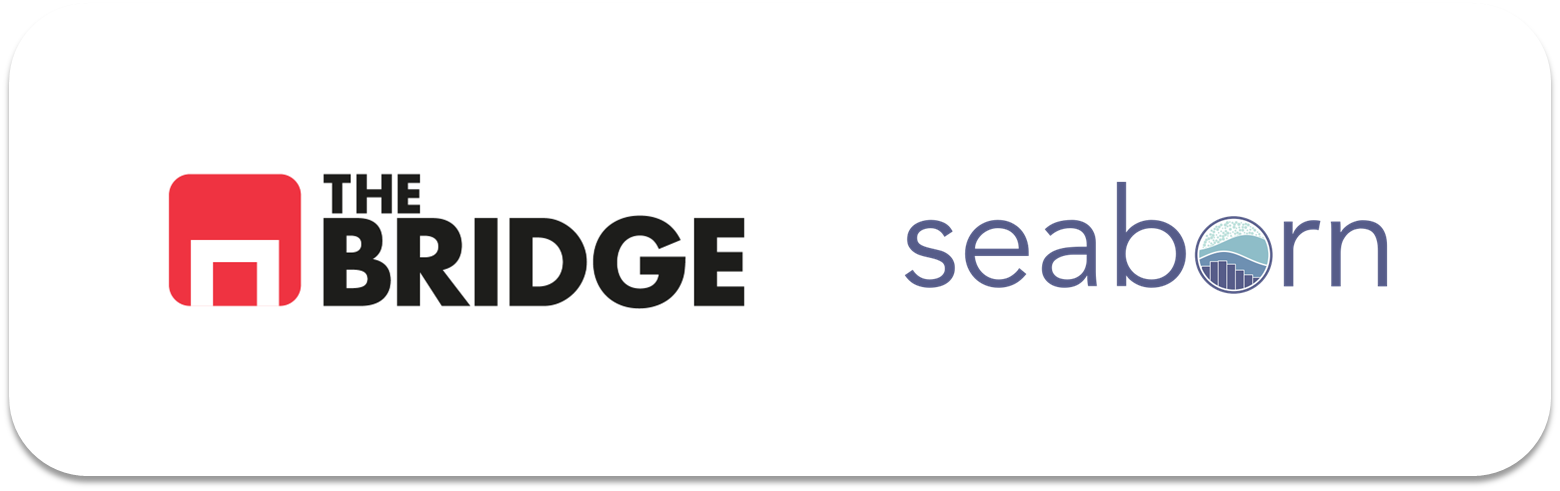

## PRACTICA OBLIGATORIA: **Visualización Avanzada y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración opcional para mejorar la estética de los gráficos
sns.set_theme(style="whitegrid")
%matplotlib inline

## #1: Visualización

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [2]:
# Cargar el dataset
df_california = pd.read_csv("./data/california_cities.csv")

In [3]:
# Mostrar información básica
print("--- Información del Dataset ---")
df_california.info()

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [4]:
# Deshacernos de las filas con nulos
df_california_clean = df_california.dropna().copy()

print(f"\nFilas tras limpieza: {len(df_california_clean)}")


Filas tras limpieza: 427


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños. NO TE PREOCUPES POR EL FORMATO DE LA LEYENDA (lo veremos en la sesión en vivo)

In [5]:
def plot_scatter(df, col_x, col_y, col_cat=None, size_arg=50, scale=1, legend=True):
    """
    Pinta un diagrama de dispersión usando Seaborn.
    
    Argumentos:
    1. df: Dataframe
    2. col_x: Columna numérica eje X
    3. col_y: Columna numérica eje Y
    4. col_cat: Columna categórica para el color (hue). Opcional.
    5. size_arg: Valor fijo para tamaño O nombre de columna para tamaño dinámico.
    6. scale: Factor para multiplicar el tamaño (si size_arg es columna).
    EXTRA: legend: Controla si se muestra la leyenda.
    """
    
    plt.figure(figsize=(12, 8))
    
    # Lógica para el tamaño de los puntos
    # Si size_arg es una cadena (nombre de columna), usamos sus valores escalados
    if isinstance(size_arg, str) and size_arg in df.columns:
        sizes = df[size_arg] * scale
    else:
        # Si es un número, usamos ese tamaño fijo (ignoramos la escala según el enunciado)
        sizes = size_arg

    # Lógica para el gráfico (con o sin hue)
    # Nota: Usamos el parámetro 's' de matplotlib que seaborn acepta para controlar el tamaño absoluto
    if col_cat:
        sns.scatterplot(
            data=df, 
            x=col_x, 
            y=col_y, 
            hue=col_cat, 
            s=sizes, 
            palette='viridis', # Un mapa de color bonito para datos continuos o categóricos
            legend=legend
        )
    else:
        sns.scatterplot(
            data=df, 
            x=col_x, 
            y=col_y, 
            s=sizes,
            legend=legend
        )
        
    plt.title(f"Diagrama de Dispersión: {col_x} vs {col_y}")
    plt.show()



### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Un ejemplo de como podría salir para que lo tengas de referencia: (olvidate de la leyenda, auque si quieres como extra puedes intentar ver cómo crearla así)

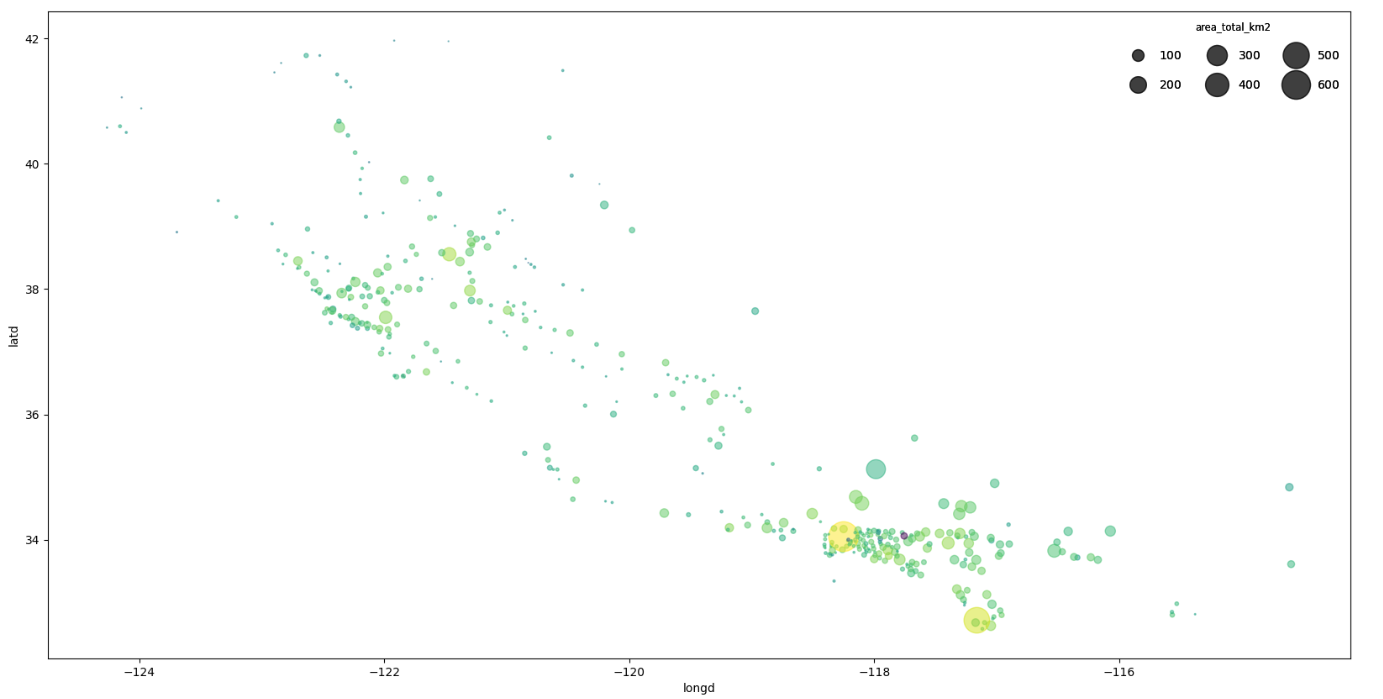

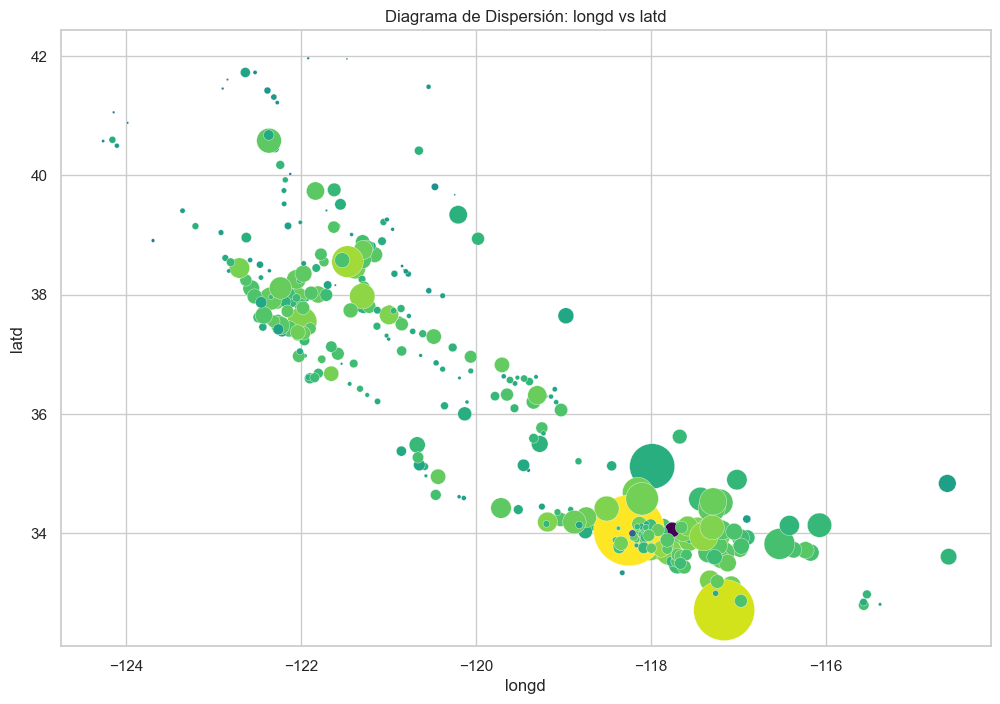

In [9]:
# 1. Crear la columna log_poblacion
df_california_clean['log_poblacion'] = np.log10(df_california_clean['population_total'])

# 2. Llamar a la función
# - Eje X: Longitud ('longd')
# - Eje Y: Latitud ('latd')
# - Color: 'log_poblacion'
# - Tamaño: 'area_total_km2'
# - Escala: 5 (Ajuste visual para que los puntos se vean bien, puedes probar con otros valores)
plot_scatter(
    df=df_california_clean, 
    col_x='longd', 
    col_y='latd', 
    col_cat='log_poblacion', 
    size_arg='area_total_km2', 
    scale=2,
    legend=False # Desactivamos la leyenda para que se parezca a la imagen de ejemplo
)

## #2: Presentación

En esta parte tendrás que hacer dos cosas:

#2.1 Crear una presentación sencilla sobre el Titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  

1. El titanic fue un accidente con una tasa de mortalidad alta.  

2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

#2.2 Las gráficas a emplear en la presentación debes generarlas en un notebook.  

Tienes que entregar ambas cosas: presentación y notebook :)

In [11]:
# Carga del Titanic
df_titanic = pd.read_csv("./data/titanic.csv")
# Vistazo rápido
print(df_titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


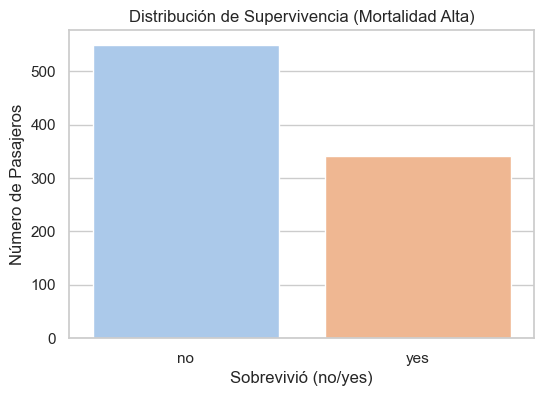

In [13]:
# Gráfica 1: Tasa de supervivencia global (Corregida)
plt.figure(figsize=(6, 4))

# CAMBIO AQUÍ: Añadimos hue='alive' y legend=False
sns.countplot(x='alive', data=df_titanic, hue='alive', palette='pastel', legend=False)

plt.title("Distribución de Supervivencia (Mortalidad Alta)")
plt.ylabel("Número de Pasajeros")
plt.xlabel("Sobrevivió (no/yes)")
plt.show()

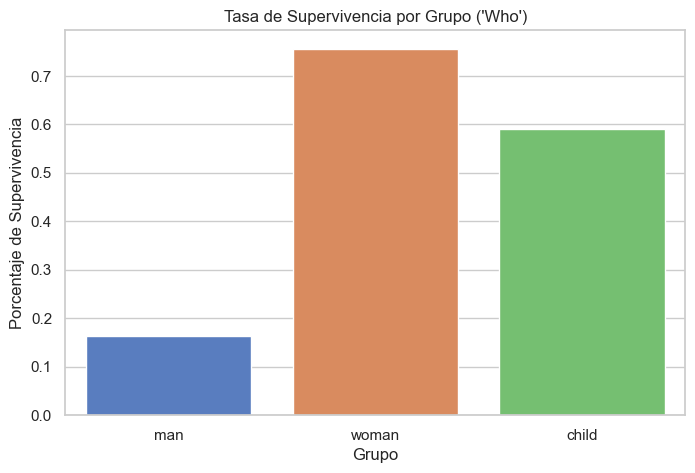

In [14]:
# Gráfica 2: Tasa de supervivencia por categoría (Corregida)
plt.figure(figsize=(8, 5))

# CORRECCIÓN: Añadido hue='who' y legend=False
sns.barplot(x='who', y='survived', data=df_titanic, hue='who', palette='muted', errorbar=None, legend=False)

plt.title("Tasa de Supervivencia por Grupo ('Who')")
plt.ylabel("Porcentaje de Supervivencia")
plt.xlabel("Grupo")
plt.show()

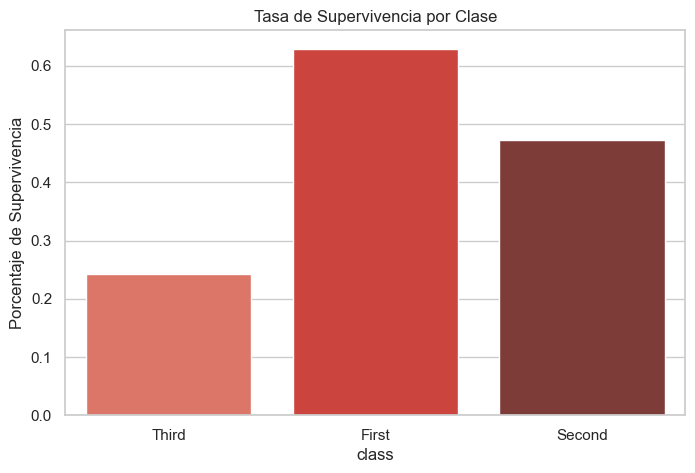

In [15]:
# Gráfica 3: Tasa de supervivencia por Clase (Corregida)
plt.figure(figsize=(8, 5))

# CORRECCIÓN: Añadido hue='class' y legend=False
sns.barplot(x='class', y='survived', data=df_titanic, hue='class', palette='Reds_d', errorbar=None, legend=False)

plt.title("Tasa de Supervivencia por Clase")
plt.ylabel("Porcentaje de Supervivencia")
plt.show()

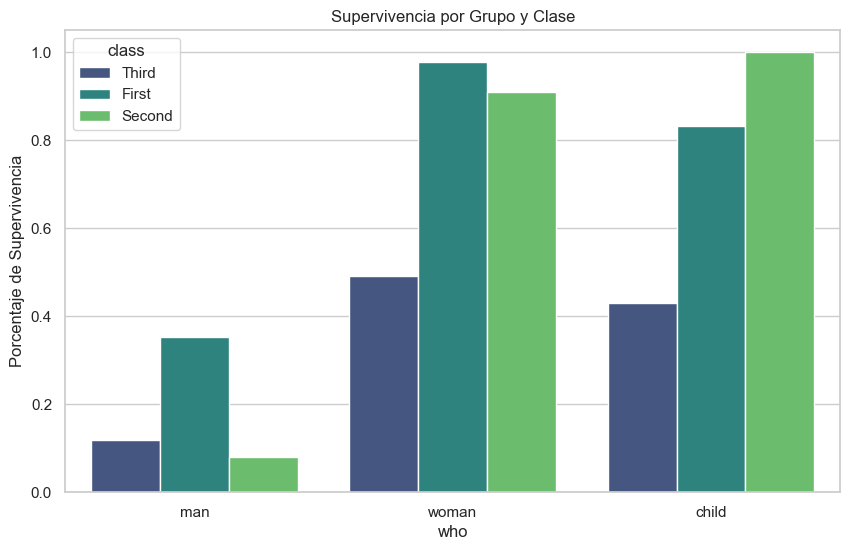

In [16]:
# Gráfica 4: Supervivencia por Grupo desglosado por Clase
plt.figure(figsize=(10, 6))
sns.barplot(x='who', y='survived', hue='class', data=df_titanic, palette='viridis', errorbar=None)
plt.title("Supervivencia por Grupo y Clase")
plt.ylabel("Porcentaje de Supervivencia")
plt.show()

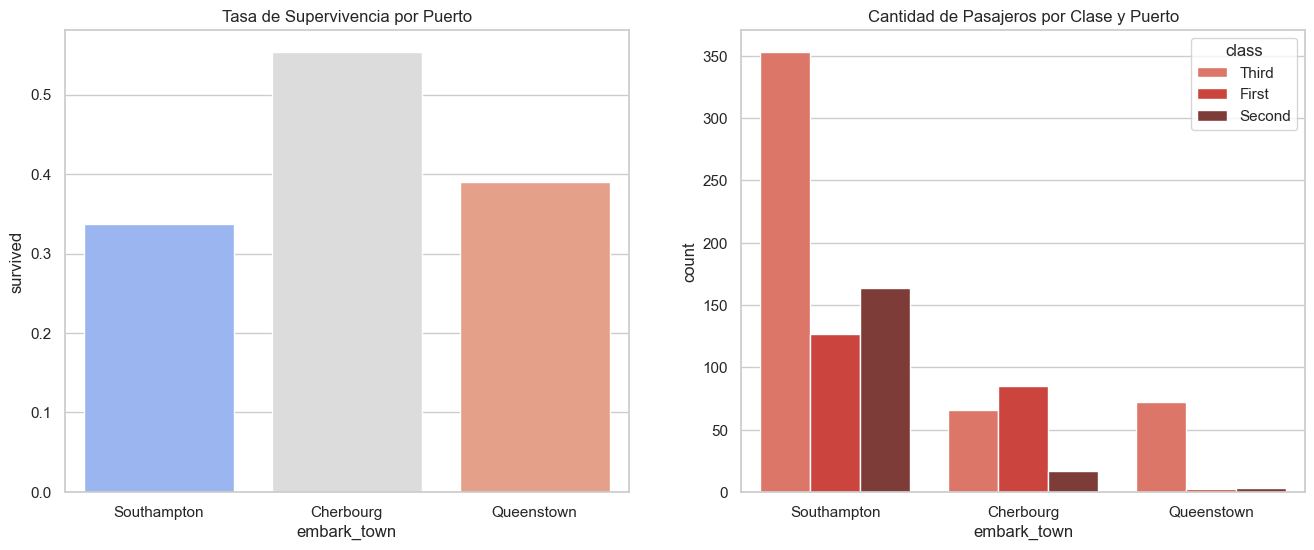

In [17]:
# Slide 5 (Corregida)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5a. Supervivencia por Puerto (CORREGIDA)
# Añadimos hue='embark_town' y legend=False
sns.barplot(x='embark_town', y='survived', data=df_titanic, hue='embark_town', ax=axes[0], palette='coolwarm', errorbar=None, legend=False)
axes[0].set_title("Tasa de Supervivencia por Puerto")

# 5b. Conteo de Clases por Puerto (ESTABA BIEN, NO SE TOCA)
# Aquí ya teníamos hue='class', así que no da error
sns.countplot(x='embark_town', hue='class', data=df_titanic, ax=axes[1], palette='Reds_d')
axes[1].set_title("Cantidad de Pasajeros por Clase y Puerto")

plt.show()